# Import libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings("ignore")
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder , OrdinalEncoder,LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import GridSearchCV
from sklearn.impute import KNNImputer
from sklearn.preprocessing import MinMaxScaler

# Reading the dataset

In [ ]:
df=pd.read_csv('synthetic_dataset_10000x20.csv')
df.head()

,customer_id,age,income,savings,monthly_expenses,num_dependents,credit_score,loan_amount,loan_term_months,employment_years,...,education,marital_status,region,recent_default,has_credit_card,signup_date,signup_dayofweek,debt_to_income,sin_age,target_default_risk
0,CUST006253,30,66737.0,11155.0,2272.0,2,605.076204,26965.0,48,3.9,...,HS,Single,West,1,1,2020-07-05,6,0.404,0.141120,1
1,CUST004685,22,70740.0,997.0,1934.0,1,683.291967,4681.0,36,0.7,...,Bachelors,Married,East,0,0,2018-10-03,2,0.066,0.808496,1
2,CUST001732,68,38890.0,1929.0,1696.0,0,658.003360,12633.0,72,2.2,...,Bachelors,Single,East,0,1,2018-05-30,2,0.325,0.494113,0
3,CUST004743,49,29049.0,6284.0,2485.0,1,707.477864,20881.0,36,2.7,...,HS,Married,South,0,1,2018-04-22,6,0.719,-0.982453,0
4,CUST004522,74,60063.0,924.0,3179.0,2,564.768511,19438.0,36,10.3,...,Masters,Single,West,0,0,2019-12-03,1,0.324,0.898708,1


In [ ]:
df.tail()

,customer_id,age,income,savings,monthly_expenses,num_dependents,credit_score,loan_amount,loan_term_months,employment_years,...,education,marital_status,region,recent_default,has_credit_card,signup_date,signup_dayofweek,debt_to_income,sin_age,target_default_risk
9995,CUST005735,54,44507.0,5975.0,2520.0,1,699.633352,31089.0,48,5.3,...,HS,Single,East,0,1,2020-02-27,3,0.699,-0.772764,1
9996,CUST005192,50,20651.0,10203.0,1020.0,3,680.774066,8977.0,60,9.6,...,PhD,Divorced,North,0,0,2018-08-23,3,0.435,-0.958924,0
9997,CUST005391,43,33827.0,3848.0,2562.0,1,655.562748,24319.0,60,4.3,...,HS,Married,West,0,0,2019-01-18,4,0.719,-0.916166,0
9998,CUST000861,44,38273.0,18880.0,1060.0,2,653.277645,1000.0,24,11.4,...,Other,Single,North,0,1,2019-08-04,6,0.026,-0.951602,0
9999,CUST007271,30,53614.0,6201.0,1310.0,1,663.975556,5205.0,60,9.8,...,Bachelors,Divorced,North,0,1,2018-03-03,5,0.097,0.141120,1


In [ ]:
df.nunique()

,0
customer_id,10000
age,57
income,9107
savings,6498
monthly_expenses,3068
num_dependents,8
credit_score,9647
loan_amount,7999
loan_term_months,6
employment_years,182


In [ ]:
df.describe()

,age,income,savings,monthly_expenses,num_dependents,credit_score,loan_amount,loan_term_months,employment_years,recent_default,has_credit_card,signup_dayofweek,debt_to_income,sin_age,target_default_risk
count,10000.000000,9682.000000,9689.000000,9675.000000,10000.000000,9674.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,45.861600,59712.871411,5039.922489,2082.209612,1.214200,650.155438,16214.796900,45.642000,5.39701,0.047000,0.694800,3.011900,0.358156,-0.100387,0.513200
std,16.457987,39865.231489,5041.793583,1385.991787,1.108982,69.918297,16081.646814,15.475134,3.41370,0.211649,0.460515,2.003986,0.302606,0.667428,0.499851
min,18.000000,20001.000000,0.000000,200.000000,0.000000,363.077116,1000.000000,12.000000,0.00000,0.000000,0.000000,0.000000,0.004000,-0.999923,0.000000
25%,32.000000,31300.500000,1476.000000,1471.000000,0.000000,602.189895,8508.500000,36.000000,2.70000,0.000000,0.000000,1.000000,0.132000,-0.756802,0.000000
50%,46.000000,47301.500000,3499.000000,2007.000000,1.000000,649.808322,15174.500000,48.000000,5.10000,0.000000,1.000000,3.000000,0.275000,-0.157746,1.000000
75%,60.000000,75164.250000,6986.000000,2557.000000,2.000000,697.537432,21843.750000,60.000000,7.70000,0.000000,1.000000,5.000000,0.508000,0.515501,1.000000
max,74.000000,402769.000000,44644.000000,28664.000000,7.000000,850.000000,441190.000000,72.000000,21.50000,1.000000,1.000000,6.000000,2.031000,0.973848,1.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   customer_id          10000 non-null  object 
 1   age                  10000 non-null  int64  
 2   income               9682 non-null   float64
 3   savings              9689 non-null   float64
 4   monthly_expenses     9675 non-null   float64
 5   num_dependents       10000 non-null  int64  
 6   credit_score         9674 non-null   float64
 7   loan_amount          10000 non-null  float64
 8   loan_term_months     10000 non-null  int64  
 9   employment_years     10000 non-null  float64
 10  home_ownership       10000 non-null  object 
 11  education            10000 non-null  object 
 12  marital_status       10000 non-null  object 
 13  region               10000 non-null  object 
 14  recent_default       10000 non-null  int64  
 15  has_credit_card      10000 non-null  

In [ ]:
df.isnull().sum()

,0
customer_id,0
age,0
income,318
savings,311
monthly_expenses,325
num_dependents,0
credit_score,326
loan_amount,0
loan_term_months,0
employment_years,0


In [ ]:
df.shape

(10000, 21)

In [ ]:
df["signup_date"] = pd.to_datetime(df["signup_date"])
df["signup_year"] = df["signup_date"].dt.year
df["signup_month"] = df["signup_date"].dt.month
df["day"] = df["signup_date"].dt.day
df["signup_dayofweek"] = df["signup_date"].dt.dayofweek

In [ ]:
df

,customer_id,age,income,savings,monthly_expenses,num_dependents,credit_score,loan_amount,loan_term_months,employment_years,...,recent_default,has_credit_card,signup_date,signup_dayofweek,debt_to_income,sin_age,target_default_risk,signup_year,signup_month,day
0,CUST006253,30,66737.0,11155.0,2272.0,2,605.076204,26965.0,48,3.9,...,1,1,2020-07-05,6,0.404,0.141120,1,2020,7,5
1,CUST004685,22,70740.0,997.0,1934.0,1,683.291967,4681.0,36,0.7,...,0,0,2018-10-03,2,0.066,0.808496,1,2018,10,3
2,CUST001732,68,38890.0,1929.0,1696.0,0,658.003360,12633.0,72,2.2,...,0,1,2018-05-30,2,0.325,0.494113,0,2018,5,30
3,CUST004743,49,29049.0,6284.0,2485.0,1,707.477864,20881.0,36,2.7,...,0,1,2018-04-22,6,0.719,-0.982453,0,2018,4,22
4,CUST004522,74,60063.0,924.0,3179.0,2,564.768511,19438.0,36,10.3,...,0,0,2019-12-03,1,0.324,0.898708,1,2019,12,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,CUST005735,54,44507.0,5975.0,2520.0,1,699.633352,31089.0,48,5.3,...,0,1,2020-02-27,3,0.699,-0.772764,1,2020,2,27
9996,CUST005192,50,20651.0,10203.0,1020.0,3,680.774066,8977.0,60,9.6,...,0,0,2018-08-23,3,0.435,-0.958924,0,2018,8,23
9997,CUST005391,43,33827.0,3848.0,2562.0,1,655.562748,24319.0,60,4.3,...,0,0,2019-01-18,4,0.719,-0.916166,0,2019,1,18
9998,CUST000861,44,38273.0,18880.0,1060.0,2,653.277645,1000.0,24,11.4,...,0,1,2019-08-04,6,0.026,-0.951602,0,2019,8,4


In [ ]:
df.drop('customer_id', axis=1, inplace=True)
df.drop('signup_date', axis=1, inplace=True)

In [ ]:
df.shape

(10000, 22)

Splitting x & y values

In [ ]:
X=df.drop("target_default_risk",axis=1)
Y=df["target_default_risk"]

In [ ]:
df["education"] = df["education"].replace({"Bachlors": "Bachelors"})

In [ ]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
9995,False
9996,False
9997,False
9998,False


In [ ]:
numerical_cols = df.select_dtypes(include=['int64',"int32",'float64']).columns.tolist()

Boxplot

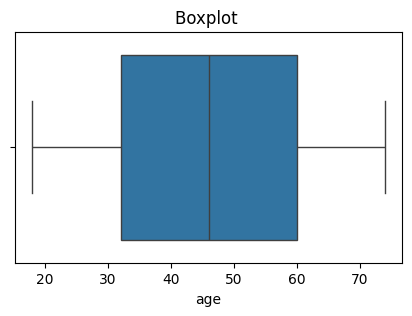

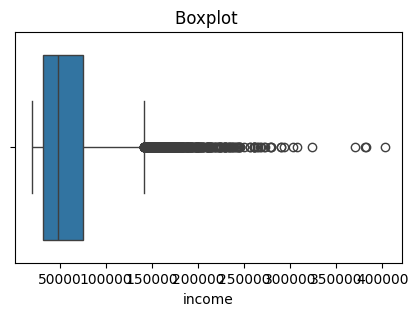

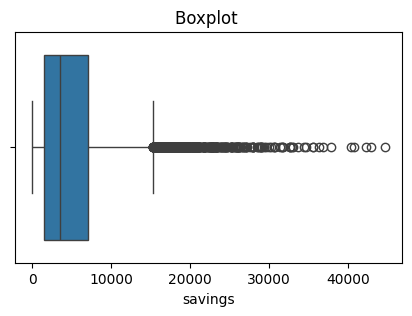

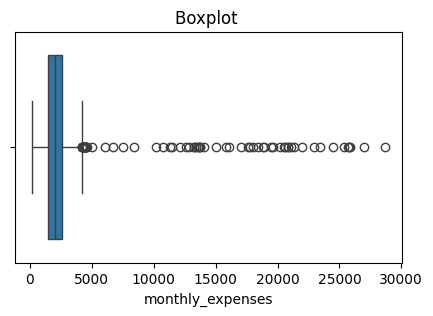

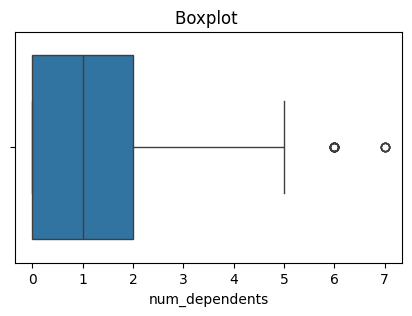

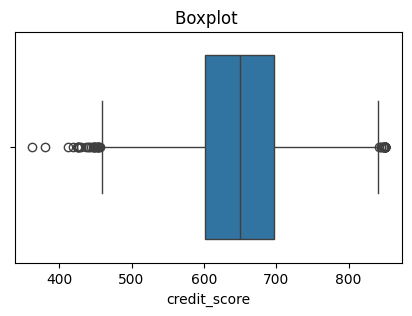

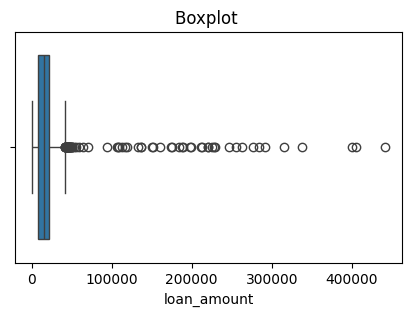

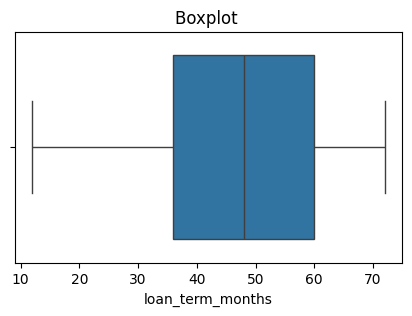

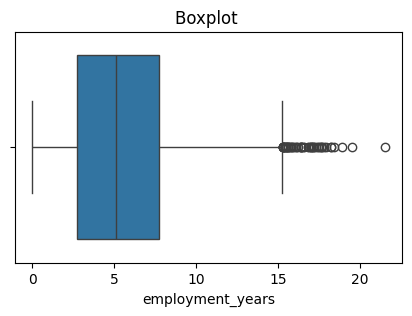

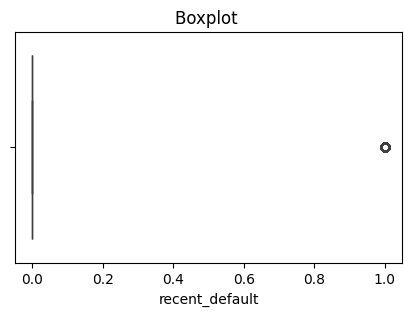

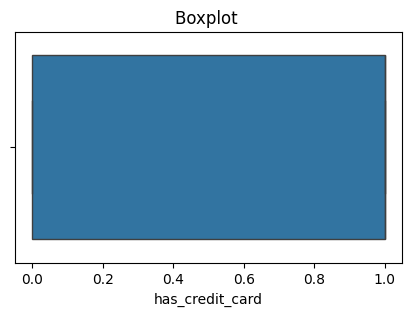

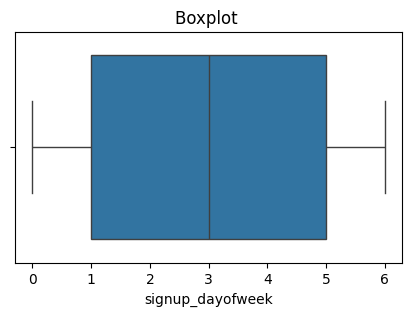

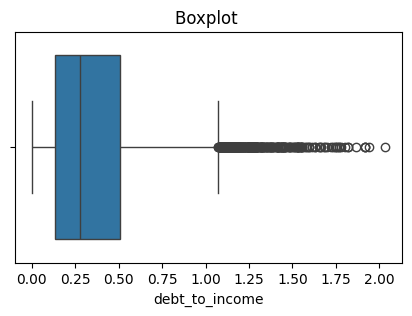

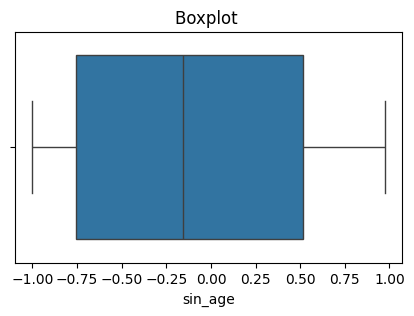

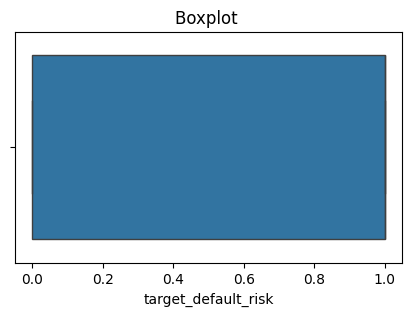

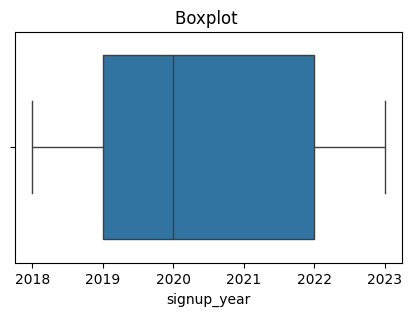

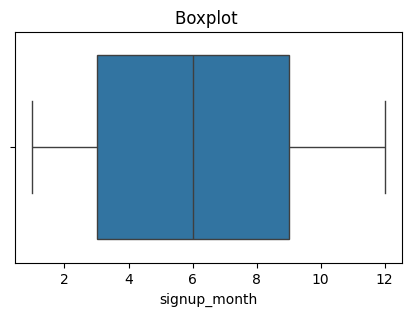

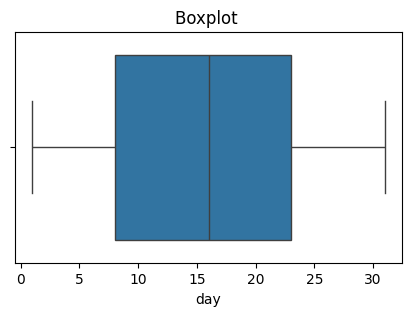

In [ ]:
for col in numerical_cols:
    plt.figure(figsize=(5,3))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot ")
    plt.show()

In [ ]:
categorical_cols = df.select_dtypes(exclude=['int64',"int32",'float64']).columns

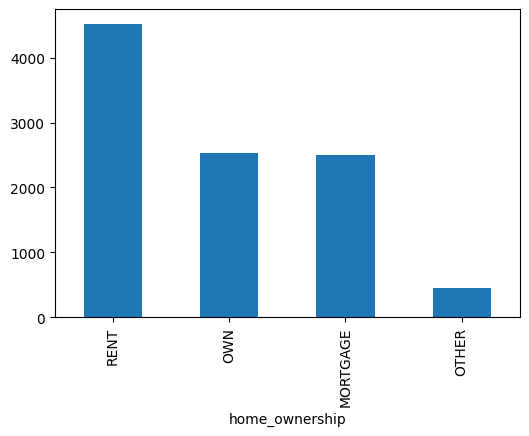

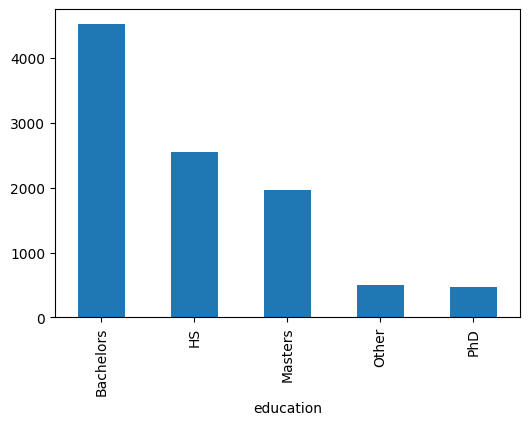

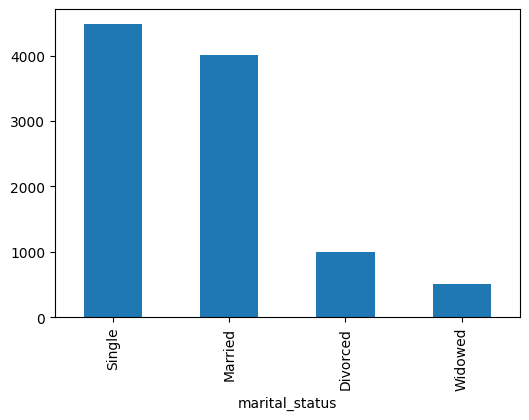

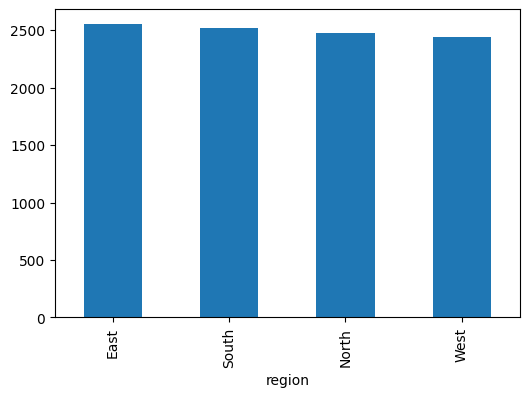

In [ ]:
for col in categorical_cols:
    plt.figure(figsize=(6,4))
    df[col].value_counts().plot(kind='bar')
    plt.show()

<Axes: >

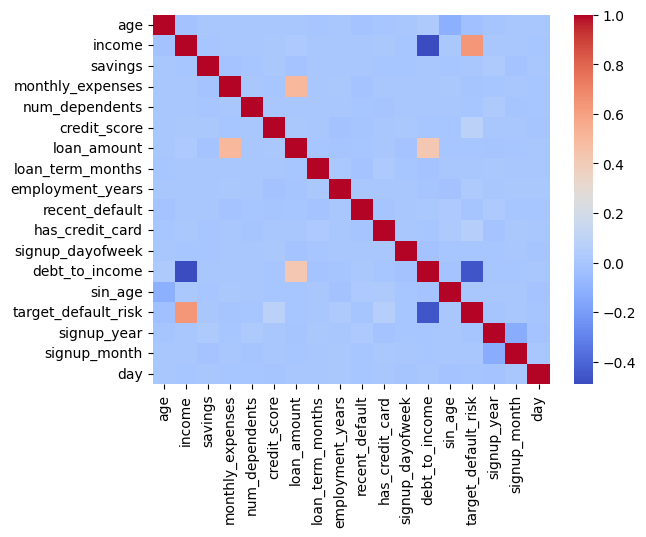

In [ ]:
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm")

In [ ]:
for i in categorical_cols:
    print(df[i].value_counts())
    print("\n")

home_ownership
RENT        4524
OWN         2526
MORTGAGE    2498
OTHER        452
Name: count, dtype: int64


education
Bachelors    4530
HS           2546
Masters      1962
Other         500
PhD           462
Name: count, dtype: int64


marital_status
Single      4486
Married     4002
Divorced    1000
Widowed      512
Name: count, dtype: int64


region
East     2553
South    2523
North    2479
West     2445
Name: count, dtype: int64




In [ ]:
X=df.drop("target_default_risk",axis=1)
Y=df["target_default_risk"]

In [ ]:
X

,age,income,savings,monthly_expenses,num_dependents,credit_score,loan_amount,loan_term_months,employment_years,home_ownership,...,marital_status,region,recent_default,has_credit_card,signup_dayofweek,debt_to_income,sin_age,signup_year,signup_month,day
0,30,66737.0,11155.0,2272.0,2,605.076204,26965.0,48,3.9,RENT,...,Single,West,1,1,6,0.404,0.141120,2020,7,5
1,22,70740.0,997.0,1934.0,1,683.291967,4681.0,36,0.7,RENT,...,Married,East,0,0,2,0.066,0.808496,2018,10,3
2,68,38890.0,1929.0,1696.0,0,658.003360,12633.0,72,2.2,OWN,...,Single,East,0,1,2,0.325,0.494113,2018,5,30
3,49,29049.0,6284.0,2485.0,1,707.477864,20881.0,36,2.7,OWN,...,Married,South,0,1,6,0.719,-0.982453,2018,4,22
4,74,60063.0,924.0,3179.0,2,564.768511,19438.0,36,10.3,MORTGAGE,...,Single,West,0,0,1,0.324,0.898708,2019,12,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,54,44507.0,5975.0,2520.0,1,699.633352,31089.0,48,5.3,RENT,...,Single,East,0,1,3,0.699,-0.772764,2020,2,27
9996,50,20651.0,10203.0,1020.0,3,680.774066,8977.0,60,9.6,RENT,...,Divorced,North,0,0,3,0.435,-0.958924,2018,8,23
9997,43,33827.0,3848.0,2562.0,1,655.562748,24319.0,60,4.3,OTHER,...,Married,West,0,0,4,0.719,-0.916166,2019,1,18
9998,44,38273.0,18880.0,1060.0,2,653.277645,1000.0,24,11.4,MORTGAGE,...,Single,North,0,1,6,0.026,-0.951602,2019,8,4


Replacing

In [ ]:
df['education'] = df['education'].replace({'Bachlors':'Bachelors'})

In [ ]:
nominal=categorical_cols.drop("education")
nominal

Index(['home_ownership', 'marital_status', 'region'], dtype='object')

In [ ]:
ordinal=["education"]
ordinal_cat=["Other", "HS", "Bachelors", "Masters", "PhD"]

In [ ]:
num_cols_1= X.select_dtypes(include=['int64',"int32",'float64']).columns

In [ ]:
for col in num_cols_1:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    df[col] = df[col].clip(lower, upper)

Column transforming

In [ ]:
numeric_transform=Pipeline(steps=[
    ("imputer",KNNImputer(n_neighbors=5)),
    ("scaler",MinMaxScaler())
])

In [ ]:
nominal_transform=Pipeline(steps=[
    ("imputer",SimpleImputer(strategy="most_frequent")),
    ("cat", OneHotEncoder(drop="first", sparse_output=False))

])

In [ ]:
ordinal_transform=Pipeline(steps=[
    ("imputer",SimpleImputer(strategy="most_frequent")),
    ("ord", OrdinalEncoder(categories=[ordinal_cat]))

])

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num",numeric_transform,num_cols_1),
        ("nominal",nominal_transform,nominal),
        ("ordinal",ordinal_transform,ordinal)
    ],remainder="passthrough"
)

In [ ]:
preprocessor.fit(df)

ColumnTransformer(remainder='passthrough',
                  transformers=[('num',
                                 Pipeline(steps=[('imputer', KNNImputer()),
                                                 ('scaler', MinMaxScaler())]),
                                 Index(['age', 'income', 'savings', 'monthly_expenses', 'num_dependents',
       'credit_score', 'loan_amount', 'loan_term_months', 'employment_years',
       'recent_default', 'has_credit_card', 'signup_dayofweek',
       'debt_to_income', 'sin_age', 's...
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                sparse_output=False))]),
                                 Index(['home_ownership', 'marital_status', 'region'], dtype='object')),
                                ('ordinal',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('ord',
                                                  OrdinalEncoder(categories=[['Other',
                                                                              'HS',
                                                                              'Bachelors',
                                                                              'Masters',
                                                                              'PhD']]))]),
                                 ['education'])])

In [ ]:
X_transformed = preprocessor.fit_transform(df)
feature_names = preprocessor.get_feature_names_out()
df_transformed = pd.DataFrame(X_transformed, columns=feature_names)

In [ ]:
df_transformed.shape

(10000, 28)

In [ ]:
df.isnull().sum()

,0
age,0
income,318
savings,311
monthly_expenses,325
num_dependents,0
credit_score,326
loan_amount,0
loan_term_months,0
employment_years,0
home_ownership,0


In [ ]:
df_transformed.head()

,num__age,num__income,num__savings,num__monthly_expenses,num__num_dependents,num__credit_score,num__loan_amount,num__loan_term_months,num__employment_years,num__recent_default,...,nominal__home_ownership_OWN,nominal__home_ownership_RENT,nominal__marital_status_Married,nominal__marital_status_Single,nominal__marital_status_Widowed,nominal__region_North,nominal__region_South,nominal__region_West,ordinal__education,remainder__target_default_risk
0,0.214286,0.386379,0.731427,0.519819,0.4,0.382568,0.635671,0.6,0.256579,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0
1,0.071429,0.419473,0.065373,0.435023,0.2,0.587649,0.090118,0.4,0.046053,0.0,...,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,2.0,1.0
2,0.892857,0.156161,0.126484,0.375314,0.0,0.521342,0.284797,1.0,0.144737,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,2.0,0.0
3,0.553571,0.074802,0.412039,0.573256,0.2,0.651064,0.486723,0.4,0.177632,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
4,1.000000,0.331203,0.060586,0.747366,0.4,0.276882,0.451396,0.4,0.677632,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,3.0,1.0


In [ ]:
df_transformed["remainder__target_default_risk"]=df_transformed["remainder__target_default_risk"].astype(int)

In [ ]:
df_transformed.isnull().sum()

,0
num__age,0
num__income,0
num__savings,0
num__monthly_expenses,0
num__num_dependents,0
num__credit_score,0
num__loan_amount,0
num__loan_term_months,0
num__employment_years,0
num__recent_default,0


In [ ]:
x_new=df_transformed.drop("remainder__target_default_risk",axis=1)
y_new=df_transformed["remainder__target_default_risk"]

In [ ]:
X_train,X_test,Y_train,Y_test=train_test_split(x_new,y_new,test_size=0.2,random_state=42)

Random forest

In [ ]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

In [ ]:
model_pipeline = Pipeline(steps=[
    (("smote", SMOTE(random_state=42))),
    ('classifier', RandomForestClassifier(random_state=42, n_jobs=-1))
])

In [ ]:
param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [10, 20, None],
    'classifier__min_samples_leaf': [1, 2, 4]
}

In [ ]:
grid_search = GridSearchCV(
    model_pipeline,
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

In [ ]:
grid_search.fit(X_train,Y_train)

Fitting 5 folds for each of 18 candidates, totalling 90 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('smote', SMOTE(random_state=42)),
                                       ('classifier',
                                        RandomForestClassifier(n_jobs=-1,
                                                               random_state=42))]),
             n_jobs=-1,
             param_grid={'classifier__max_depth': [10, 20, None],
                         'classifier__min_samples_leaf': [1, 2, 4],
                         'classifier__n_estimators': [100, 200]},
             scoring='accuracy', verbose=1)

In [ ]:
print(grid_search.best_params_)

{'classifier__max_depth': 20, 'classifier__min_samples_leaf': 1, 'classifier__n_estimators': 100}


In [ ]:
model_pipeline.fit(X_train, Y_train)

Pipeline(steps=[('smote', SMOTE(random_state=42)),
                ('classifier',
                 RandomForestClassifier(n_jobs=-1, random_state=42))])

In [ ]:
y_pred=model_pipeline.predict(X_test)
y_pred

array([0, 0, 1, ..., 0, 1, 0])

In [ ]:
grid_search_accuracy=accuracy_score(y_pred,Y_test)
grid_search_accuracy

0.9435

In [ ]:
RFC=RandomForestClassifier(max_depth=20,min_samples_leaf=1,n_estimators=100)
RFC.fit(X_train,Y_train)
y_pred_rfc=RFC.predict(X_test)
randon_accuracy=accuracy_score(Y_test,y_pred_rfc)
randon_accuracy

0.942

Logistic Regression

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test=train_test_split(x_new,y_new,test_size=0.2,random_state=42)
from sklearn.linear_model import LogisticRegression
model=LogisticRegression()
model.fit(X_train,Y_train)
ypred=model.predict(X_test)
ypred
logistic_accuracy=accuracy_score(Y_test,ypred)
logistic_accuracy

0.932

In [ ]:
param_grid = {
    'penalty': ['l1', 'l2', 'elasticnet', 'none'],
    'C': np.logspace(-4, 4, 20), # A range of C values on a log scale
    'solver': ['liblinear', 'saga'], # 'liblinear' and 'saga' support multiple penalties
    'max_iter': [100, 1000, 2500]
}

In [ ]:
grid_search_log = GridSearchCV(estimator=model, param_grid=param_grid, cv=5, n_jobs=-1, verbose=2)

In [ ]:
grid_search_log.fit(X_train,Y_train)

Fitting 5 folds for each of 480 candidates, totalling 2400 fits


GridSearchCV(cv=5, estimator=LogisticRegression(), n_jobs=-1,
             param_grid={'C': array([1.00000000e-04, 2.63665090e-04, 6.95192796e-04, 1.83298071e-03,
       4.83293024e-03, 1.27427499e-02, 3.35981829e-02, 8.85866790e-02,
       2.33572147e-01, 6.15848211e-01, 1.62377674e+00, 4.28133240e+00,
       1.12883789e+01, 2.97635144e+01, 7.84759970e+01, 2.06913808e+02,
       5.45559478e+02, 1.43844989e+03, 3.79269019e+03, 1.00000000e+04]),
                         'max_iter': [100, 1000, 2500],
                         'penalty': ['l1', 'l2', 'elasticnet', 'none'],
                         'solver': ['liblinear', 'saga']},
             verbose=2)

In [ ]:
grid_search_log.best_params_

{'C': np.float64(0.615848211066026),
 'max_iter': 100,
 'penalty': 'l1',
 'solver': 'saga'}

In [ ]:
grid_search.best_score_

np.float64(0.930875)

In [ ]:
logistic_accuracy=accuracy_score(Y_test,ypred)
logistic_accuracy

0.932

Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, Y_train)
y_pred_dt = dt_model.predict(X_test)
decision_accuracy=accuracy_score(Y_test, y_pred_dt)
decision_accuracy

0.9175

In [ ]:
param_grid = {
    'criterion': ['gini', 'entropy'],     # The function to measure the quality of a split
    'max_depth': [5, 10, 20, 30, None],   # Maximum depth of the tree (None means no limit)
    'min_samples_split': [2, 5, 10, 20],  # Minimum number of samples required to split a node
    'min_samples_leaf': [1, 2, 4, 8]      # Minimum number of samples required at each leaf node
}

In [ ]:
grid_search_dt = GridSearchCV(estimator=dt_model, param_grid=param_grid, cv=5, n_jobs=-1, verbose=2)

In [ ]:
grid_search_dt.fit(X_train, Y_train)

Fitting 5 folds for each of 160 candidates, totalling 800 fits


GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [5, 10, 20, 30, None],
                         'min_samples_leaf': [1, 2, 4, 8],
                         'min_samples_split': [2, 5, 10, 20]},
             verbose=2)

In [ ]:
best_dt = grid_search_dt.best_estimator_
accuracy = best_dt.score(X_test, Y_test)
print(best_dt)
print(accuracy)

DecisionTreeClassifier(criterion='entropy', max_depth=10, min_samples_leaf=8,
                       min_samples_split=20, random_state=42)
0.9465


XG Boost

In [ ]:
!pip install xgboost

In [ ]:
from xgboost import XGBClassifier

In [ ]:
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

In [ ]:
param_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'n_estimators': [100, 200, 300],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

In [ ]:
grid_search_xg = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    cv=3,
    n_jobs=-1,
    verbose=2
)

In [ ]:
grid_search_xg.fit(X_train, Y_train)

Fitting 3 folds for each of 108 candidates, totalling 324 fits


GridSearchCV(cv=3,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='logloss', feature_types=None,
                                     feature_weights=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraint...
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.8, 1.0],
                         'learning_rate': [0.01, 0.1, 0.2],
                         'max_depth': [3, 5, 7],
                         'n_estimators': [100, 200, 300],
                         'subsample': [0.8, 1.0]},
             verbose=2)

In [ ]:
best_xgb = grid_search_xg.best_estimator_
xgboost_accuracy=accuracy = best_xgb.score(X_test, Y_test)

In [ ]:
xgboost_accuracy

0.95

SVM

In [ ]:
from sklearn.svm import SVC

In [ ]:
model=SVC()

In [ ]:
param_grid = {
    'C': [0.1, 1, 10, 100],          # Regularization parameter
    'gamma': [1, 0.1, 0.01, 0.001],    # Kernel coefficient
    'kernel': ['rbf', 'poly']          # Type of kernel
}

In [ ]:
grid_search_sv= GridSearchCV(estimator=model, param_grid=param_grid, cv=5, n_jobs=-1, verbose=2)

In [ ]:
grid_search_sv.fit(X_train, Y_train)

Fitting 5 folds for each of 32 candidates, totalling 160 fits


GridSearchCV(cv=5, estimator=SVC(), n_jobs=-1,
             param_grid={'C': [0.1, 1, 10, 100], 'gamma': [1, 0.1, 0.01, 0.001],
                         'kernel': ['rbf', 'poly']},
             verbose=2)

In [ ]:
print("\nBest parameters found: ", grid_search_sv.best_params_)
print("Best cross-validation score: {:.2f}".format(grid_search_sv.best_score_))


Best parameters found:  {'C': 100, 'gamma': 0.001, 'kernel': 'rbf'}
Best cross-validation score: 0.93


In [ ]:
best_model= grid_search_sv.best_estimator_
xgb_accuracy=best_model.score(X_test,Y_test)

In [ ]:
xgb_accuracy

0.938

# Perceptron

In [ ]:
from sklearn.linear_model import Perceptron
from sklearn.metrics import classification_report
perceptron_clf=Perceptron(max_iter=1000,eta0=1.0,random_state=42)
perceptron_clf.fit(X_train,Y_train)
y_pred_perc=perceptron_clf.predict(X_test)
print("Perceptron Accuracy:" ,accuracy_score(Y_test,y_pred_perc))
print(classification_report(Y_test,y_pred_perc))

Perceptron Accuracy: 0.908
              precision    recall  f1-score   support

           0       0.91      0.90      0.90       969
           1       0.91      0.92      0.91      1031

    accuracy                           0.91      2000
   macro avg       0.91      0.91      0.91      2000
weighted avg       0.91      0.91      0.91      2000



MLP

In [ ]:
from sklearn.neural_network import MLPClassifier
mlp_clf=MLPClassifier(hidden_layer_sizes=(50,30),activation='relu',solver='adam',max_iter=500,random_state=42)
mlp_clf.fit(X_train,Y_train)

MLPClassifier(hidden_layer_sizes=(50, 30), max_iter=500, random_state=42)

In [ ]:
y_pred_mlp=mlp_clf.predict(X_test)
print("MLPClassifier acuuracy:",accuracy_score(Y_test,y_pred_mlp))
print(classification_report(Y_test, y_pred_mlp))

MLPClassifier acuuracy: 0.9325
              precision    recall  f1-score   support

           0       0.95      0.90      0.93       969
           1       0.91      0.96      0.94      1031

    accuracy                           0.93      2000
   macro avg       0.93      0.93      0.93      2000
weighted avg       0.93      0.93      0.93      2000



Tensorflow

In [ ]:
!pip install tensorflow

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
y_train_tf=keras.utils.to_categorical(Y_train,num_classes=3)
y_test_tf=keras.utils.to_categorical(Y_test,num_classes=3)
model=keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(64,activation='relu'),
    layers.Dense(32,activation='relu'),
    layers.Dense(3,activation='softmax')
])
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
history=model.fit(X_train,y_train_tf,epochs=50,batch_size=8,validation_split=0.2)

Epoch 1/50
800/800 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7254 - loss: 0.5713 - val_accuracy: 0.8969 - val_loss: 0.3139
Epoch 2/50
800/800 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9084 - loss: 0.2844 - val_accuracy: 0.9175 - val_loss: 0.2871
Epoch 3/50
800/800 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9119 - loss: 0.2655 - val_accuracy: 0.9137 - val_loss: 0.2828
Epoch 4/50
800/800 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9170 - loss: 0.2599 - val_accuracy: 0.9169 - val_loss: 0.2795
Epoch 5/50
800/800 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9152 - loss: 0.2576 - val_accuracy: 0.9300 - val_loss: 0.2592
Epoch 6/50
800/800 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9271 - loss: 0.2354 - val_accuracy: 0.9237 - val_loss: 0.2540
Epoch 7/50
800/800 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9315 - loss: 0.2293 - val_accuracy: 0.9294 - val_loss: 0.2500
Epoch 8/50
800/800 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9286 - loss: 0.2304 - val_accuracy: 0.

In [ ]:
loss,acc=model.evaluate(X_test,y_test_tf)
print("tensorflow MLP test accuracy:(acc:.4f)")

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9093 - loss: 0.3506
tensorflow MLP test accuracy:(acc:.4f)
